<a href="https://colab.research.google.com/github/hsicatowoUST/COMP4211/blob/main/COMP4211Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Packages

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import json
import re
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

In [ ]:
from tensorflow.keras import layers, models, optimizers, Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout,BatchNormalization, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical  # for 1-hot
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.utils import shuffle
from tqdm import tqdm
from sklearn.linear_model import SGDClassifier



from transformers import pipeline, BertTokenizer, TFBertModel



# sentences = ["I am not having a great day"]

# model_outputs = classifier(sentences)
# print(model_outputs[0])

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout, Dense

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │          16,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# load scam dataset
scam1_df = pd.read_csv("hf://datasets/BothBosu/Scammer-Conversation/gen_conver_noIdentifier_1000.csv")

splits = {'train': 'scam-dialogue_train.csv', 'test': 'scam-dialogue_test.csv'}
scam2_df = pd.read_csv("hf://datasets/BothBosu/scam-dialogue/" + splits["train"])
scam2_df.drop(columns=['type'])
scam2_df.rename(columns={"dialogue":'conversation'}, inplace=True)
scam2_df.head()

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


,conversation,type,label
0,"caller: Hello, is this John? receiver: Yes, it...",ssn,1
1,"caller: Hello, is this John? receiver: Yeah, t...",ssn,1
2,"caller: Hello, is this Mr. Johnson? receiver: ...",ssn,1
3,"caller: Hello, is this John? receiver: Yeah, t...",ssn,1
4,"caller: Hello, this is Officer Johnson from th...",ssn,1


#1. Data Preprocessing

We write a function for preprocessing the data

`line_by_line`: It decomposes the conversation into setences and removes the speakers' names from the text,  meanwhile, keeping track of the which conversation it is and the speakers in a dataframe.

## 1.1 Scam datasets


In [ ]:
def line_by_line(df, conversation_column, preserve_columns, speaker_a, speaker_b):
    """
    Process a DataFrame to split conversation lines into separate rows and add additional columns.

    Parameters:
    df (pd.DataFrame): The original DataFrame.
    conversation_column (str): The name of the column containing the conversation text.
    preserve_columns (list): List of columns to preserve in the new DataFrame.
    speaker_a (str): The string identifying speaker A.
    speaker_b (str): The string identifying speaker B.

    Returns:
    pd.DataFrame: A new DataFrame with each conversation line as a separate row and additional columns.
    """

    # Function to split and combine conversation lines
    def split_and_combine_conversation(conversation):
        # Adjust the regex pattern to use the provided speaker identifiers
        parts = re.split(r'({}|{})'.format(re.escape(speaker_a), re.escape(speaker_b)), conversation)
        combined_utterances = []
        current_speaker = None
        current_utterance = ""

        for part in parts:
            if part.startswith(speaker_a):
                if current_speaker == 'A':
                    current_utterance += " "
                else:
                    if current_utterance:
                        combined_utterances.append((current_speaker, current_utterance.strip()))
                    current_speaker = 'A'
                    current_utterance = ""
                current_utterance += part[len(speaker_a):].strip()
            elif part.startswith(speaker_b):
                if current_speaker == 'B':
                    current_utterance += " "
                else:
                    if current_utterance:
                        combined_utterances.append((current_speaker, current_utterance.strip()))
                    current_speaker = 'B'
                    current_utterance = ""
                current_utterance += part[len(speaker_b):].strip()
            else:
                current_utterance += " " + part.strip()

        if current_utterance:
            combined_utterances.append((current_speaker, current_utterance.strip()))

        return combined_utterances

    # Create a list to store the new rows
    new_rows = []

    for index, row in df.iterrows():
        combined_utterances = split_and_combine_conversation(row[conversation_column])
        utterance_id = 0

        for speaker, utterance in combined_utterances:
            if speaker:
                new_row = {col: row[col] for col in preserve_columns}
                new_row[conversation_column] = utterance
                new_row['conversation_id'] = index
                new_row['utterance_id'] = utterance_id
                new_row['speaker'] = speaker
                new_rows.append(new_row)
                utterance_id += 1

    # Create a new DataFrame from the new rows
    new_df = pd.DataFrame(new_rows)
    new_df[conversation_column] = new_df[conversation_column].str.lower()
    return new_df

In [ ]:
scam1_line_by_line = line_by_line(scam1_df, 'conversation', ['label'], 'Person A:', 'Person B:')
scam2_line_by_line = line_by_line(scam2_df, 'conversation', ['label'], 'caller:', 'receiver:')
scam2_line_by_line['conversation_id'] = scam2_line_by_line['conversation_id'] + (scam1_line_by_line['conversation_id'].iloc[-1] + 1)
scam2_line_by_line

,label,conversation,conversation_id,utterance_id,speaker
0,1,"hello, is this john?",1000,0,A
1,1,"yes, it is. who's calling?",1000,1,B
2,1,my name is officer johnson from the social sec...,1000,2,A
3,1,"i'm fine, thank you. what can i do for you?",1000,3,B
4,1,we've been trying to reach you about a very im...,1000,4,A
...,...,...,...,...,...
17465,0,"no, i don't know him. but i can try looking up...",2279,7,B
17466,0,"okay, thanks so much.",2279,8,A
17467,0,"okay, i've got a few listings for john smith i...",2279,9,B
17468,0,"that would be great, thank you.",2279,10,A


Final datasets for training:
* `extract_speaker_df1`: The whole conversation as a string, scam label, and speaker sequece vector. To be used in training MLP in model 1.
* `line_by_line`: Conversation seperated into lines. Will be labeled with emotion by pre-trained BERT (model 2).

In [ ]:
line_by_line_df = pd.concat([scam1_line_by_line, scam2_line_by_line]).reset_index(drop=True)

## 1.2 Extract emotions

Get the emotion label using a pretrained bert model
store in the google drive

The following codes use pretrained bert to get the emotion labels. (It takes some time to run everytime, so we directly store it in drive)

In [ ]:
# pretrained roberta-model
emotion_classifier = pipeline(task="text-classification", model="SamLowe/roberta-base-go_emotions", top_k=None, device=0)
sentences = line_by_line_df['conversation'].tolist()
# get the emotions labels for sentences
results = emotion_classifier(sentences)

# store them in df
labels = [sublist[0]['label'] for sublist in results]
line_by_line_df['emotions'] = labels
line_by_line_df = line_by_line_df.dropna(subset=['conversation'])

# store in google drive
csv_path = '/content/drive/MyDrive/COMP4211/project/line_by_line.csv'
line_by_line_df.to_csv(csv_path, index=False)


config.json:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

In [ ]:
setence = ["The machine learning project is fun."]
results = emotion_classifier(setence)
labels =[ [item['label'] for item in sublist] for sublist in results][0]
probs = [[item['score'] for item in sublist] for sublist in results][0]
df = pd.DataFrame([probs],index = ['probability'],columns = labels)

,joy,amusement,admiration,neutral,approval,excitement,optimism,realization,relief,love,...,confusion,disappointment,anger,surprise,nervousness,embarrassment,fear,disgust,remorse,grief
probability,0.709654,0.507302,0.049253,0.030565,0.028722,0.023901,0.008447,0.007715,0.006807,0.005898,...,0.002268,0.001637,0.001467,0.001381,0.00102,0.000889,0.000799,0.000705,0.000686,0.000578


In [ ]:

# emotion_classifier = pipeline(task="text-classification", model="SamLowe/roberta-base-go_emotions", top_k=None, device=0)
# def visualize_prediction(num_samples):
#   sentences = line_by_line_df['conversation'].tolist()[0:num_samples]
#   results = emotion_classifier(sentences)
#   converted_results = [ [' '.join(f"{value:.3f}" if isinstance(value, float) else str(value) for value in item.values()) for item in sublist] for sublist in results]
#   display(pd.DataFrame(converted_results))
# visualize_prediction(3)

In [ ]:
# Create the one-hot encoding dictionary
emotions = [
    "admiration",
    "amusement",
    "anger",
    "annoyance",
    "approval",
    "caring",
    "confusion",
    "curiosity",
    "desire",
    "disappointment",
    "disapproval",
    "disgust",
    "embarrassment",
    "excitement",
    "fear",
    "gratitude",
    "grief",
    "joy",
    "love",
    "nervousness",
    "optimism",
    "pride",
    "realization",
    "relief",
    "remorse",
    "sadness",
    "surprise",
    "neutral"
]

# Create one-hot encoding dictionary
one_hot_dict = {emotion: [1 if i == j else 0 for i in range(len(emotions))] for j, emotion in enumerate(emotions)}

# Define the function to one-hot encode a list of emotions
def one_hot_encode_emotions(emotion_list):
    return [one_hot_dict[emotion] for emotion in emotion_list]


In [ ]:
# the line_by_line_df can be retrived from the google drive
csv_path = '/content/drive/MyDrive/COMP4211/project/line_by_line.csv'
line_by_line_df = pd.read_csv(csv_path)
line_by_line_df['conversation'] = line_by_line_df['conversation'].astype(str)

In [ ]:
# group the line by line together by their id
group_line_by_line_df = line_by_line_df.groupby('conversation_id', sort=False).agg({
    'conversation':lambda x:' '.join(x),
    'speaker': list,
    'emotions':list,
    'label': lambda x: x.iloc[0]
})
group_line_by_line_df.reset_index(inplace=True)
group_line_by_line_df['one_hot_encoded'] = group_line_by_line_df['emotions'].apply(one_hot_encode_emotions)

In [ ]:
# add the number of lines in each conversation
group_line_by_line_df['length'] = group_line_by_line_df['speaker'].apply(len)
group_line_by_line_df

,conversation_id,conversation,speaker,emotions,label,one_hot_encoded,length
0,0,"hello, i'm calling from the bank and need to v...","[A, B, A, B, A, B, A, B]","[neutral, curiosity, neutral, curiosity, neutr...",1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",8
1,1,"hi, how was your weekend? it was great! i visi...","[A, B, A, B, A, B, A, B, A, B, A]","[curiosity, admiration, curiosity, joy, love, ...",0,"[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,...",11
2,2,"hello, this is sarah from the credit card comp...","[A, B, A, B, A, B, A, B]","[neutral, curiosity, neutral, curiosity, disap...",1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",8
3,3,"hey, how's your week going so far? hey, not ba...","[A, B, A, B, A, B, A, B, A, B, A, B, A]","[curiosity, gratitude, neutral, excitement, su...",0,"[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,...",13
4,4,"good day, i'm calling from a lottery company t...","[A, B, A, B, A, B, A, B, A, B]","[joy, curiosity, neutral, curiosity, disapprov...",1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",10
...,...,...,...,...,...,...,...
2275,2275,"hi, is this 555-1234? no, this is 555-5678. yo...","[A, B, A, B, A, B, A, B]","[neutral, disapproval, remorse, neutral, grati...",0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",8
2276,2276,"hello, is this 555-1234? yes, it is. who's cal...","[A, B, A, B, A, B, A, B]","[neutral, approval, curiosity, fear, remorse, ...",0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",8
2277,2277,"hi, is this 555-1234? no, this is 555-1245. yo...","[A, B, A, B, A, B]","[neutral, disapproval, remorse, neutral, grati...",0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",6
2278,2278,"hi, is john there? there is no john here. you ...","[A, B, A, B, A, B, A, B]","[neutral, neutral, remorse, curiosity, curiosi...",0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",8


In [ ]:
print(group_line_by_line_df['length'].mode())

0    8
Name: length, dtype: int64


group_line_by_line is our final dataset

## 1.3 Spliting dataset for training

We will split our dataset `group_line_by_line_df` into 3 parts.
One for pretraining the first 3 models, the second one for the last regression model, and the final one is for testing.

In [ ]:
# split dataset into three partitions
def shuffle_split(df, partition_sizes):
    """
    Shuffle and split a DataFrame into partitions of specified sizes.

    Args:
        df (pd.DataFrame): Input DataFrame to be shuffled and split.
        partition_sizes (list): List of fractions for partition sizes. Should sum to 1.0.

    Returns:
        list: List of DataFrame partitions.
    """
    if not np.isclose(sum(partition_sizes), 1.0):
        raise ValueError("Partition sizes must sum to 1.0")

    # Shuffle the DataFrame
    shuffled_df = df.sample(frac=1, random_state=4211).reset_index(drop=True)

    # Calculate the number of rows for each partition, ensuring all data is included
    total_rows = len(shuffled_df)
    partition_counts = [int(size * total_rows) for size in partition_sizes]

    # Adjust the last partition to include any leftover rows
    partition_counts[-1] += total_rows - sum(partition_counts)

    # Calculate partition indices
    partition_indices = np.cumsum([0] + partition_counts)

    # Split the shuffled DataFrame into partitions
    df_parts = [shuffled_df.iloc[partition_indices[i]:partition_indices[i + 1]].reset_index(drop=True) for i in range(len(partition_sizes))]

    return df_parts

partition_sizes = [0.5, 0.2, 0.3]
data1, data2, data3 = shuffle_split(group_line_by_line_df, partition_sizes)

In [ ]:
data1.head()

,conversation_id,conversation,speaker,emotions,label,one_hot_encoded
0,948,"hi, how's your day going? it's been great, tha...","[A, B, A, B, A, B, A, B, A, B, A, B, A]","[curiosity, admiration, approval, curiosity, j...",0,"[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,..."
1,927,"good morning, i'm calling from the insurance c...","[A, B, A, B, A, B, A, B]","[neutral, curiosity, approval, curiosity, disa...",1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2,1060,"hello, this is officer johnson from the social...","[A, B, A, B, A, B, A, B, A, B, A, B, A, B, A, ...","[neutral, surprise, neutral, curiosity, neutra...",1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3,863,"good afternoon, i'm calling from the phone com...","[A, B, A, B, A, B, A, B]","[neutral, curiosity, approval, curiosity, disa...",1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
4,181,"hi, how have you been lately? i've been great,...","[A, B, A, B, A, B, A, B, A, B, A, B, A]","[curiosity, admiration, approval, curiosity, a...",0,"[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,..."


Prepare dataset for Longformer+MLP

In [ ]:
mlp_data = data1[['conversation', 'label']]

Prepare dataset for LSTM

`select_elements`: It will combine the emotion sequence from the same speaker.

In [ ]:
# prepare dataset for LSTMs
def select_elements(row, letter):
  return [val2 for val1, val2 in zip(row['speaker'], row['one_hot_encoded']) if val1 == letter]

# sentences spoken by speaker A
A_df = data1.apply(lambda row: select_elements(row, 'A'), axis=1).to_frame(name='emotion_sequence')
A_df['label'] = data1['label']

# sentences spoken by speaker B
B_df = data1.apply(lambda row: select_elements(row, 'B'), axis=1).to_frame(name='emotion_sequence')
B_df['label'] = data1['label']
B_df


,emotion_sequence,label
0,"[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0
1,"[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,...",1
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1
3,"[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,...",1
4,"[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0
...,...,...
1135,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0
1136,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0
1137,"[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,...",0
1138,"[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,...",1


In [ ]:
# first 10 data
display(A_df.iloc[0:10])
display(B_df.iloc[0:10])

,emotion_sequence,label
0,"[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,...",0
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1
4,"[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,...",0
5,"[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,...",0
6,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1
7,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0
8,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1
9,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0


,emotion_sequence,label
0,"[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0
1,"[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,...",1
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1
3,"[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,...",1
4,"[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0
5,"[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0
6,"[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,...",1
7,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0
8,"[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,...",1
9,"[[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0


# 2. Training

## 2.1 Longformer+MLP Training

We use Longformer to get a good embedding of conversation text and feed it in a MLP for classification task.

In [ ]:
# Load pre-trained Longformer model and preprocessor from TensorFlow Hub
from transformers import LongformerTokenizer, TFLongformerModel
# Initialize the tokenizer and model
tokenizer = LongformerTokenizer.from_pretrained('allenai/longformer-base-4096')
long_model = TFLongformerModel.from_pretrained('allenai/longformer-base-4096')



/usr/local/lib/python3.10/dist-packages/tf_keras/src/initializers/initializers.py:121: UserWarning: The initializer TruncatedNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(
Some layers from the model checkpoint at allenai/longformer-base-4096 were not used when initializing TFLongformerModel: ['lm_head']
- This IS expected if you are initializing TFLongformerModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFLongformerModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model

In [ ]:
# Function to get pooler_output for a batch of texts
# Input: a list of sentences (s,)
# output: tensor (s,768)
def get_pooler_outputs(texts):
    # Ensure texts is a list of sentences
    if isinstance(texts, str):
        texts = [texts]

    # Tokenize inputs
    encoded_inputs = tokenizer(
        texts,
        return_tensors='tf',
        max_length=4096,
        truncation=True,
        padding=True
    )

    # Get model outputs
    outputs = long_model(**encoded_inputs)
    pooler_outputs = outputs.pooler_output  # Shape: (batch_size, 768)

    return pooler_outputs


In [ ]:
# def check_empty_entries(texts):
#   empty_indices = [index for index, text in enumerate(texts) if text.strip() == ""]
#   return empty_indices
# check_empty_entries(mlp_data)
# mlp_train_X, mlp_val_X, mlp_train_y, mlp_val_y = train_test_split(mlp_data['conversation'].tolist(), mlp_data['label'].tolist(), test_size=0.2, random_state=4211)
# check_empty_entries(mlp_train_X)
# check_empty_entries(mlp_val_X)
# len(mlp_val_X)

We convert conversations to embeddings batch-wise since the computation resource is limited.

In [ ]:
# split the data
mlp_train_X, mlp_val_X, mlp_train_y, mlp_val_y = train_test_split(mlp_data['conversation'].tolist(), mlp_data['label'].tolist(), test_size=0.2, random_state=4211)

# convert the conversation to embeddings batch-wise
def convert_embeddings_batchwise(texts, batch_size=32):
  num_batches = len(texts)//batch_size + (1 if len(texts)% batch_size != 0 else 0)
  all_embeddings = []

  for i in range(num_batches):

    batch_texts = texts[i*batch_size:(i+1)*batch_size]
    batch_embeddings = get_pooler_outputs(batch_texts).numpy()
    all_embeddings.extend(batch_embeddings)

  return np.array(all_embeddings)




In [ ]:
mlp_train_embeddings = convert_embeddings_batchwise(mlp_train_X, 32)
mlp_val_embeddings = convert_embeddings_batchwise(mlp_val_X, 32)


# Function to save embeddings to a file
def save_embeddings(embeddings, file_path):
    with open(file_path, 'wb') as file:
        pickle.dump(embeddings, file)

save_embeddings(mlp_train_embeddings, '/content/drive/My Drive/COMP4211/project/mlp_train_embeddings.pkl')
save_embeddings(mlp_val_embeddings, '/content/drive/My Drive/COMP4211/project/mlp_val_embeddings.pkl')

In [ ]:
# def compare_embeddings(embed1, embed2):
#   return np.allclose(embed1, embed2)

We've already computed and stored them in google drive, so we can directly retrive them

In [ ]:
# Function to load embeddings from a file
def load_embeddings(file_path):
    with open(file_path, 'rb') as file:
        embeddings = pickle.load(file)
    return embeddings

mlp_train_embeddings = load_embeddings('/content/drive/My Drive/COMP4211/project/mlp_train_embeddings.pkl')
mlp_val_embeddings = load_embeddings('/content/drive/My Drive/COMP4211/project/mlp_val_embeddings.pkl')
print(mlp_train_embeddings.shape, mlp_val_embeddings.shape)

(912, 768) (228, 768)


In [ ]:
# Model definition (Model 1 MLP)
model1 = Sequential([
    Dense(128, activation='relu', input_shape=(768,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training parameters
epochs = 15
batch_size = 16

# Convert labels to numpy array
mlp_train_y = np.array(mlp_train_y)
mlp_val_y = np.array(mlp_val_y)

# Define the ModelCheckpoint callback to save the best model based on validation accuracy
checkpoint_filepath = '/content/drive/My Drive/COMP4211/project/best_mlp_model.weights.h5'
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Train the model with the callback
model1.fit(
    mlp_train_embeddings, mlp_train_y,
    validation_data=(mlp_val_embeddings, mlp_val_y),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[model_checkpoint_callback]
)

# Load the best weights after training
model1.load_weights(checkpoint_filepath)

# Now, the model has the best weights based on validation accuracy


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
31/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4717 - loss: 0.7145 
Epoch 1: val_accuracy improved from -inf to 0.50439, saving model to /content/drive/My Drive/COMP4211/project/best_mlp_model.weights.h5
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4702 - loss: 0.7150 - val_accuracy: 0.5044 - val_loss: 0.6908
Epoch 2/15
31/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5411 - loss: 0.6927 
Epoch 2: val_accuracy improved from 0.50439 to 0.81579, saving model to /content/drive/My Drive/COMP4211/project/best_mlp_model.weights.h5
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5319 - loss: 0.6933 - val_accuracy: 0.8158 - val_loss: 0.6898
Epoch 3/15
32/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5550 - loss: 0.6905  
Epoch 3: val_accuracy did not improve from 0.81579
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5464 - loss: 0.6905 - val_accuracy: 0.5044 - val_loss: 0.6863
Epoch 4/15
47/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5809 - l

In [ ]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          98,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 320,261 (1.22 MB)

 Trainable params: 106,753 (417.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 213,508 (834.02 KB)

In [ ]:
# a function for displaying confusion matrix
def display_confusion_matrix(model, val_data, val_labels):
  val_pred = model.predict(val_data)
  val_pred = np.array(val_pred)>=0.5
  cm = confusion_matrix(val_labels, val_pred)

  accuracy = accuracy_score(val_labels, val_pred)
  f1 = f1_score(val_labels, val_pred, average='weighted')
  plt.figure(figsize=(10,7))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
  plt.xlabel("Prediction")
  plt.ylabel("True Labels")
  plt.title('Confusion Matrix')
  plt.show()

  print(f"Accuracy: {accuracy:.4f}")
  print(f"F1 score: {f1}")




8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


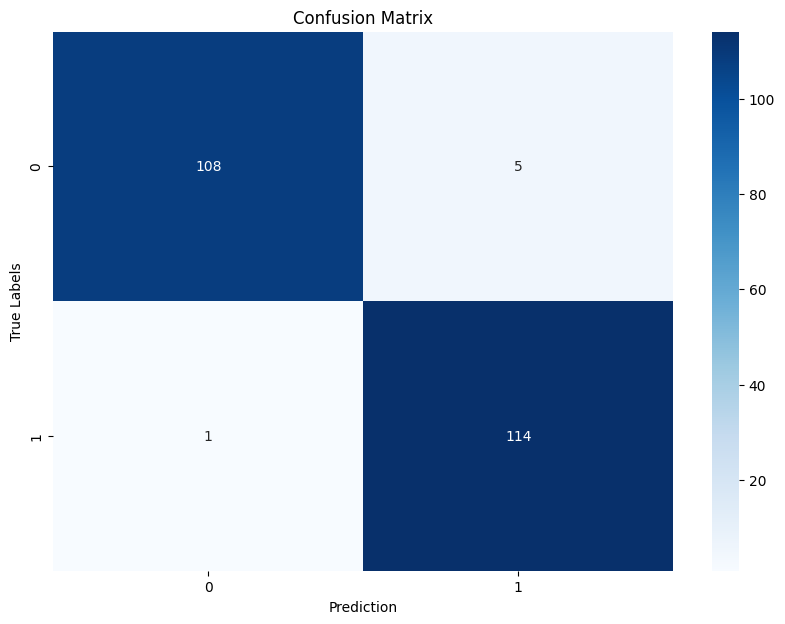

Accuracy: 0.9737
F1 score: 0.9736720526194209


In [ ]:
display_confusion_matrix(model1, mlp_val_embeddings, mlp_val_y)

## 2.2 LSTMs Training

We train 2 LSTM models (scammer/victim) for scam classification with one-hot encoded emotions sequences as inputs.

In [ ]:
A_train, A_test, B_train, B_test = train_test_split(A_df, B_df, test_size=0.2, random_state=4211)

In [ ]:
print(type(A_train))
B_test.head()

<class 'pandas.core.frame.DataFrame'>


,emotion_sequence,label
18,"[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,...",0
1067,"[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0
448,"[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,...",1
502,"[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,...",1
911,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0


In [ ]:
print(A_train.shape, A_test.shape)

(912, 2) (228, 2)


In [ ]:
def generate_batches_and_pad(data, labels, batch_size):
    """
    Generate mini-batches and pad sequences.

    Args:
        data (list of lists): List of sequences.
        labels (list): List of labels corresponding to the sequences.
        batch_size (int): Size of each mini-batch.

    Returns:
        padded_data: Padded data for each batch.
        padded_labels: Labels for the batches.
    """
    padded_data = pad_sequences(data, padding='post', dtype='float32')
    return padded_data, np.array(labels)

def build_rnn_model():
    """
    Build and compile an RNN (LSTM) model.

    Returns:
        model: Compiled RNN model.
    """
    model = Sequential([
        LSTM(6, input_shape=(None, 28), return_sequences=False),
        BatchNormalization(),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def train_rnn(model_type, training_data, training_labels, val_data, val_labels, epochs=10, batch_size=32):
    """
    Train an RNN (LSTM) model on sequences with varying lengths.

    Args:
        model_type (str): The type of RNN model ('A' or 'B').
        training_data (list of lists): List of sequences, where each sequence is a list of vectors.
        training_labels (list): Binary labels for each sequence.
        val_data (list of lists): List of validation sequences.
        val_labels (list): Binary labels for each validation sequence.
        epochs (int): Number of training epochs.
        batch_size (int): Size of each mini-batch.

    Returns:
        model: Trained RNN model.
    """

    # Generate and pad batches for training and validation data
    padded_training_data, padded_training_labels = generate_batches_and_pad(training_data, training_labels, batch_size)
    padded_val_data, padded_val_labels = generate_batches_and_pad(val_data, val_labels, len(val_labels))

    # Build the RNN model
    model = build_rnn_model()

    # Adjust the checkpoint file path based on the model type
    checkpoint_filepath = f'/content/drive/My Drive/COMP4211/project/best_rnn_model_{model_type}.weights.h5'
    model_checkpoint_callback = ModelCheckpoint(
        filepath=checkpoint_filepath,
        save_weights_only=True,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    )

    # Train the model using Keras's fit method
    model.fit(
        padded_training_data, padded_training_labels,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(padded_val_data, padded_val_labels),
        callbacks=[model_checkpoint_callback]
    )

    # Load the best weights after training
    model.load_weights(checkpoint_filepath)

    return model



In [ ]:
# Train the model
model3 = train_rnn('A', A_train['emotion_sequence'], A_train['label'], A_test["emotion_sequence"], A_test['label'], epochs=10, batch_size=16)


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4517 - loss: 0.7711
Epoch 1: val_accuracy improved from -inf to 0.71053, saving model to /content/drive/My Drive/COMP4211/project/best_rnn_model_A.weights.h5
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4599 - loss: 0.7670 - val_accuracy: 0.7105 - val_loss: 0.6829
Epoch 2/10
56/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7413 - loss: 0.5709
Epoch 2: val_accuracy improved from 0.71053 to 0.81140, saving model to /content/drive/My Drive/COMP4211/project/best_rnn_model_A.weights.h5
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7410 - loss: 0.5698 - val_accuracy: 0.8114 - val_loss: 0.6499
Epoch 3/10
53/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7349 - loss: 0.4825
Epoch 3: val_accuracy did not improve from 0.81140
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7385 - loss: 0.4804 - val_accuracy: 0.7895 - val_loss: 0.6086
Epoch 4/10
54/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8122 - loss: 0.4230

In [ ]:
model3.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 6)                   │             840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 6)                   │              24 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               7 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,591 (10.12 KB)

 Trainable params: 859 (3.36 KB)

 Non-trainable params: 12 (48.00 B)

 Optimizer params: 1,720 (6.72 KB)

In [ ]:
model4 = train_rnn('B',B_train['emotion_sequence'], B_train['label'],B_test['emotion_sequence'],B_test['label'],  epochs=15, batch_size=16)


Epoch 1/15
54/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5569 - loss: 0.6525
Epoch 1: val_accuracy improved from -inf to 0.51754, saving model to /content/drive/My Drive/COMP4211/project/best_rnn_model_B.weights.h5
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5635 - loss: 0.6461 - val_accuracy: 0.5175 - val_loss: 0.6624
Epoch 2/15
47/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8234 - loss: 0.3960
Epoch 2: val_accuracy improved from 0.51754 to 0.62281, saving model to /content/drive/My Drive/COMP4211/project/best_rnn_model_B.weights.h5
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8276 - loss: 0.3921 - val_accuracy: 0.6228 - val_loss: 0.6185
Epoch 3/15
56/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9080 - loss: 0.2930
Epoch 3: val_accuracy improved from 0.62281 to 0.84649, saving model to /content/drive/My Drive/COMP4211/project/best_rnn_model_B.weights.h5
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9079 - loss: 0.2921 - val_accuracy: 0.8465 -

In [ ]:
model4.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 6)                   │             840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 6)                   │              24 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │               7 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,591 (10.12 KB)

 Trainable params: 859 (3.36 KB)

 Non-trainable params: 12 (48.00 B)

 Optimizer params: 1,720 (6.72 KB)

It's crucial  to pad data before sending into RNN (LSTM).

In [ ]:
# notice that we have to padd the data before we send it to model!
def pad_data(data):
  return pad_sequences(data, padding='post', dtype = 'float32')

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


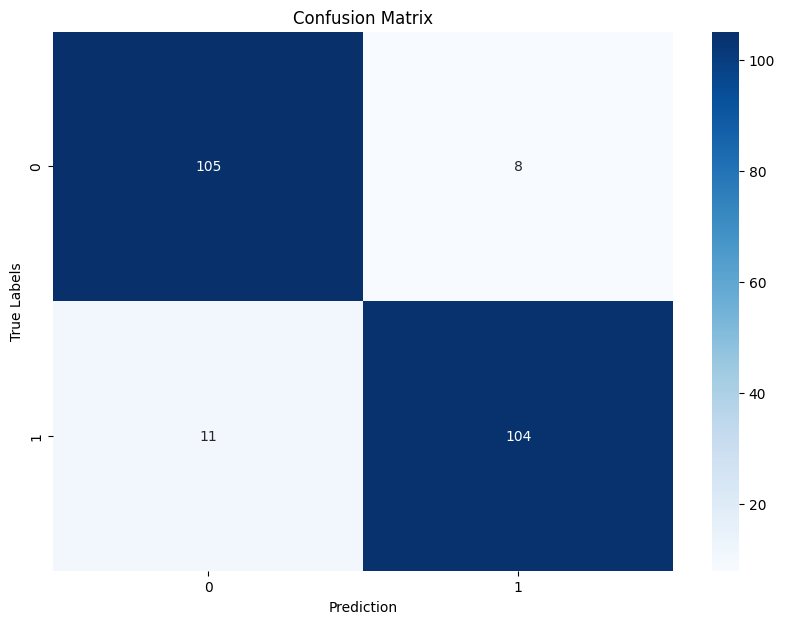

Accuracy: 0.9167
F1 score: 0.9166618574020994
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


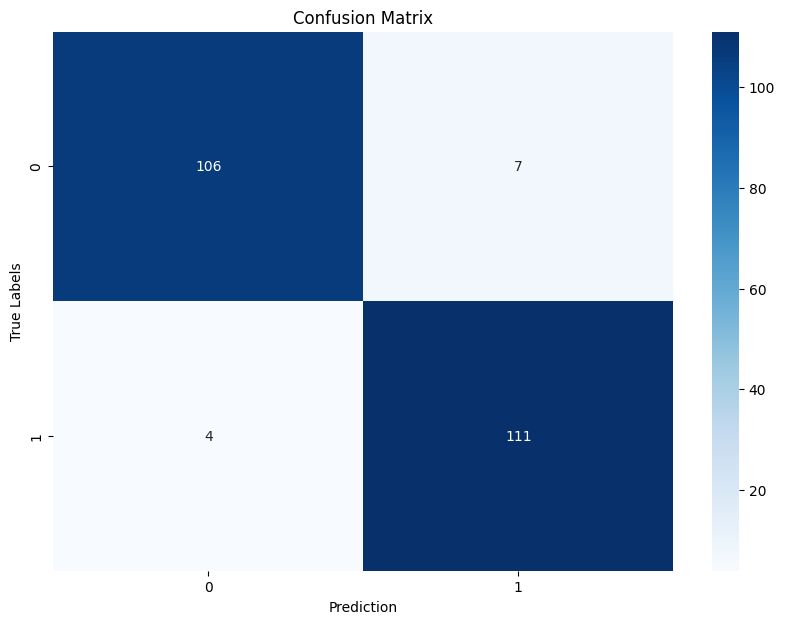

Accuracy: 0.9518
F1 score: 0.9517404579791826


In [ ]:
display_confusion_matrix(model3, pad_data(A_test['emotion_sequence']), np.array(A_test['label']))
display_confusion_matrix(model4, pad_data(B_test['emotion_sequence']), np.array(B_test['label']))

## 2.3 Logistic Regression Training

In [ ]:
def log_reg_df(data_embeddings, A_df, B_df):
  prob1 = model1.predict(data_embeddings).reshape(-1)
  prob3 = model3.predict(A_df).reshape(-1)
  prob4 = model4.predict(B_df).reshape(-1)
  X = pd.DataFrame()
  X['prob1'] = prob1
  X['prob3'] = prob3
  X['prob4'] = prob4
  return X

In [ ]:
# data trainsformed by model1
data2_embeddings = convert_embeddings_batchwise(data2['conversation'].tolist())
prob1 = model1.predict(data2_embeddings).reshape(-1)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [ ]:
# data trainsformed by model3 and model4
A_df2 = data2.apply(lambda row: select_elements(row, 'A'), axis=1).to_frame(name='emotion_sequence')
B_df2 = data2.apply(lambda row: select_elements(row, 'B'), axis=1).to_frame(name='emotion_sequence')

A_df2 = pad_data(A_df2['emotion_sequence'])
B_df2 = pad_data(B_df2['emotion_sequence'])

prob3 = model3.predict(A_df2).reshape(-1)
prob4 = model4.predict(B_df2).reshape(-1)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [ ]:
X = pd.DataFrame()
X['prob1'] = prob1
X['prob3'] = prob3
X['prob4'] = prob4
y = data2['label']
display(X.head())

,prob1,prob3,prob4
0,0.209369,0.062047,0.005831
1,0.986068,0.619357,0.945991
2,0.060660,0.018851,0.275454
3,0.066906,0.367004,0.757221
4,0.486468,0.548103,0.985822


In [ ]:
train_X, val_X, train_y, val_y = train_test_split(X,y, test_size = 0.2, random_state=4211)

In [ ]:
log_reg = SGDClassifier(loss='log_loss', penalty='l2', max_iter=1000, tol=1e-3)
log_reg.fit(train_X, train_y)
print("Coefficients (weights)", log_reg.coef_)
print("Intercept (bias)", log_reg.intercept_)

Coefficients (weights) [[12.618852   2.3326898  6.6205225]]
Intercept (bias) [-11.93664641]


In [ ]:


# Your specified directory
directory = '/content/drive/My Drive/COMP4211/project/'

# Ensure the directory exists
os.makedirs(directory, exist_ok=True)

# File path
file_path = os.path.join(directory, 'log_reg_weights.json')

# Your weights
data = {
    "coefficients": log_reg.coef_.tolist(),
    "intercept": log_reg.intercept_.tolist()
}

# Save weights to JSON file
with open(file_path, 'w') as json_file:
    json.dump(data, json_file)


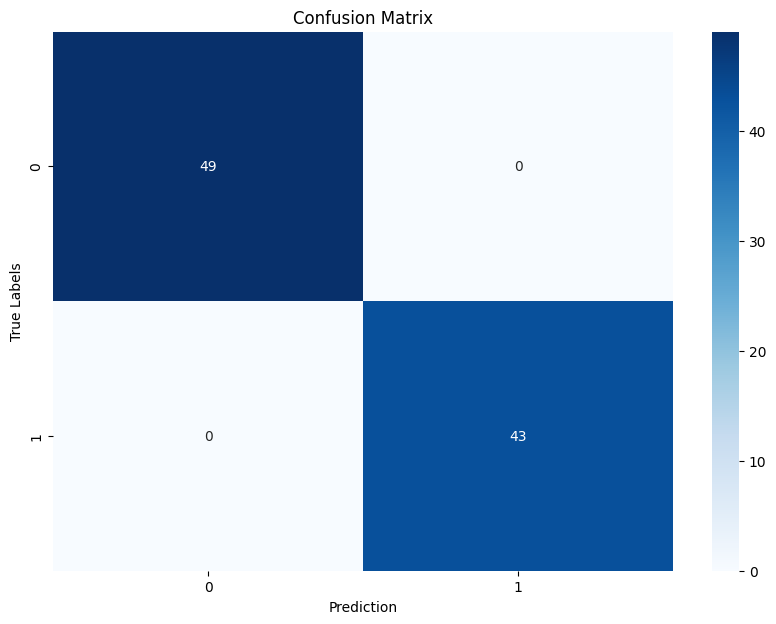

Accuracy: 1.0000
F1 score: 1.0


In [ ]:
display_confusion_matrix(log_reg, val_X, val_y)

# 3. Evaluating Performance

We use data3 for testing the performance of different (combinations of) models

In [ ]:
data3_embeddings = convert_embeddings_batchwise(data3['conversation'].tolist())
A_df3 = data3.apply(lambda row: select_elements(row, 'A'), axis=1).to_frame(name='emotion_sequence')
B_df3 = data3.apply(lambda row: select_elements(row, 'B'), axis=1).to_frame(name='emotion_sequence')
A_df3 = pad_data(A_df3['emotion_sequence'])
B_df3 = pad_data(B_df3['emotion_sequence'])

## 3.1 Model 1 only

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


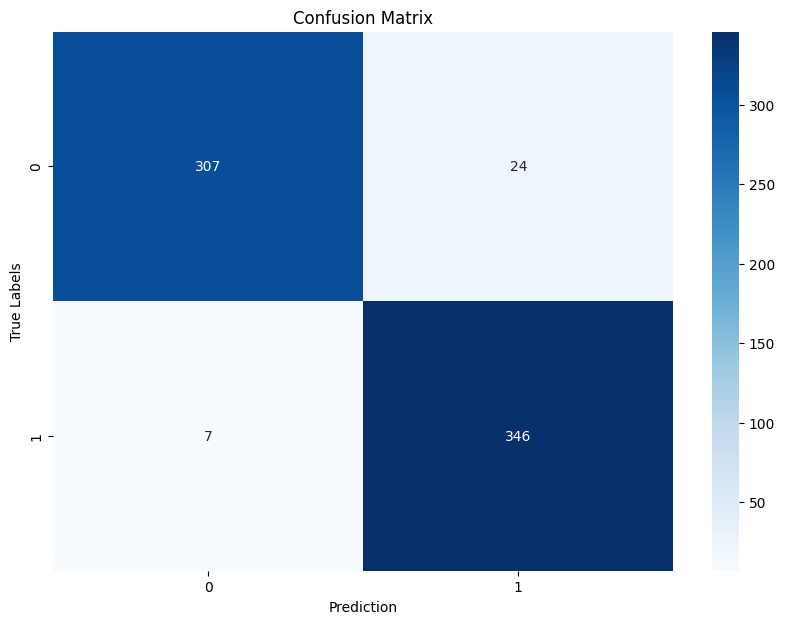

Accuracy: 0.9547
F1 score: 0.9546139276805564


In [ ]:
display_confusion_matrix(model1, data3_embeddings, data3['label'])

## 3.2 Model 3 only

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


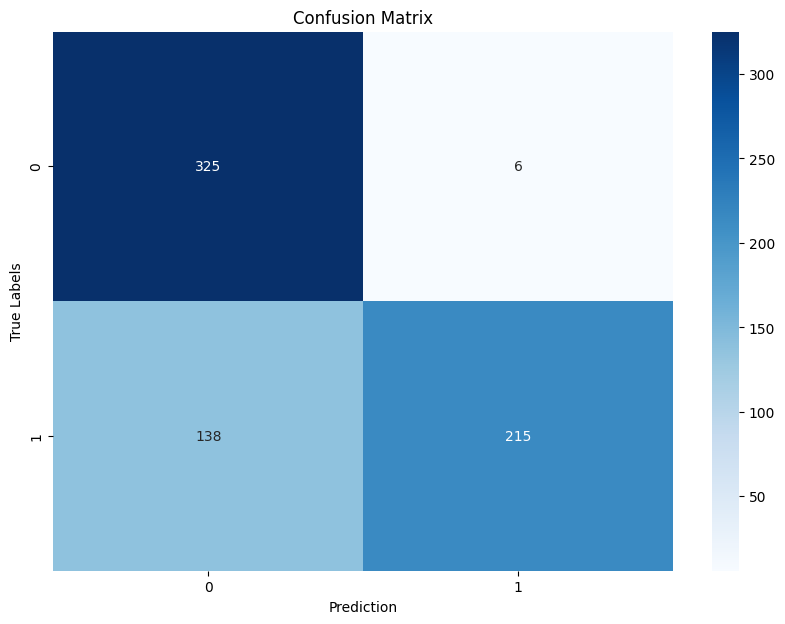

Accuracy: 0.7895
F1 score: 0.78276649416747


In [ ]:
display_confusion_matrix(model3, A_df3, data3['label'])

## 3.3 Model 4 only


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


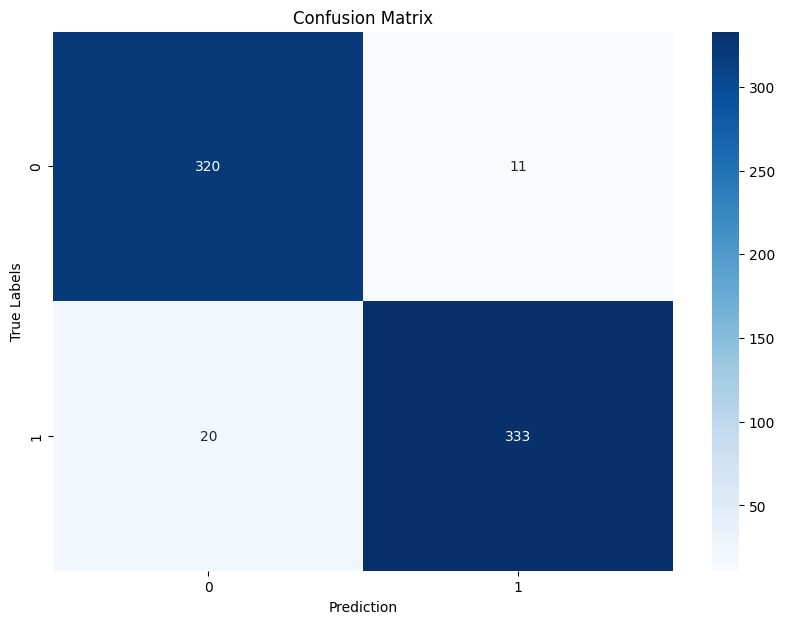

Accuracy: 0.9547
F1 score: 0.9546897005653441


In [ ]:
display_confusion_matrix(model4, B_df3, data3['label'])

## 3.4 Model 5

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


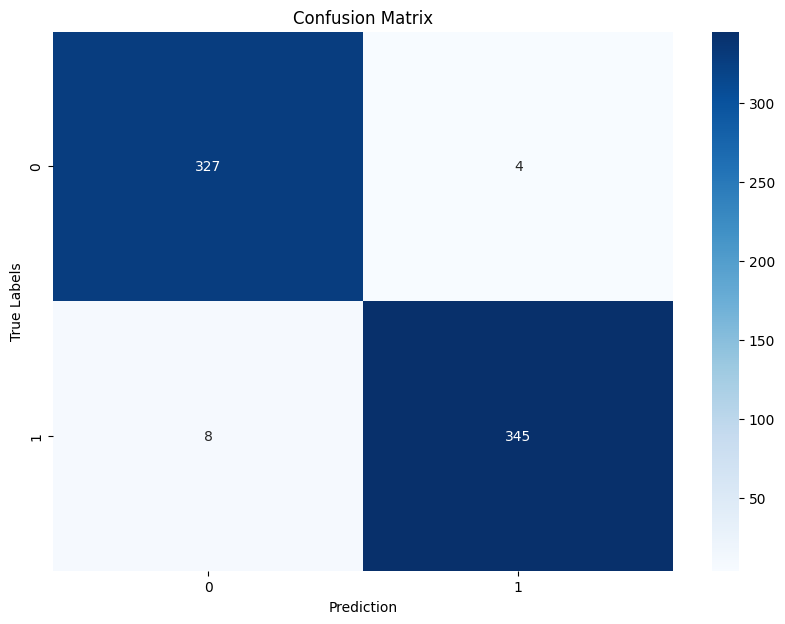

Accuracy: 0.9825
F1 score: 0.9824588421079649


In [ ]:
X = log_reg_df(data3_embeddings, A_df3, B_df3)
display_confusion_matrix(log_reg, X, data3['label'])


# 4. Discussion about Model 5 performance

## 4.1 Loading weights

We load the weights stored previously.

In [ ]:
model1 = Sequential([
    Dense(128, activation='relu', input_shape=(768,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model1.load_weights("/content/drive/My Drive/COMP4211/project/best_mlp_model.weights.h5")
model3 = Sequential([
        LSTM(6, input_shape=(None, 28), return_sequences=False),
        BatchNormalization(),
        Dense(1, activation='sigmoid')
    ])
model3.load_weights('/content/drive/My Drive/COMP4211/project/best_rnn_model_A.weights.h5')
model4 = Sequential([
        LSTM(6, input_shape=(None, 28), return_sequences=False),
        BatchNormalization(),
        Dense(1, activation='sigmoid')
    ])
model4.load_weights('/content/drive/My Drive/COMP4211/project/best_rnn_model_B.weights.h5')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Your specified directory
directory = '/content/drive/My Drive/COMP4211/project/'

# File path
file_path = os.path.join(directory, 'log_reg_weights.json')

# Load the weights from the JSON file
with open(file_path, 'r') as json_file:
    weights = json.load(json_file)

model5 = SGDClassifier(loss='log_loss', penalty='l2', max_iter=1000, tol=1e-3, fit_intercept=True, random_state=4211)
model5.fit(X, data3['label']) # fake fitting
model5.coef_ = np.array(weights['coefficients'])
model5.intercept_ = np.array(weights['intercept'])

## 4.2 Collect predictions

We store the predictions of the four models in `Summary`

In [ ]:
X = log_reg_df(data3_embeddings, A_df3,B_df3)
Summary = X.copy(deep=True)
Summary['pred of M1'] = (model1.predict(data3_embeddings)>=0.5).astype(int)
Summary['pred of M3'] = (model3.predict(A_df3)>=0.5).astype(int)
Summary['pred of M4'] = (model4.predict(B_df3)>=0.5).astype(int)
Summary['pred of M5'] = model5.predict(X)
Summary['label']= data3['label']
Summary

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


,prob1,prob3,prob4,pred of M1,pred of M3,pred of M4,pred of M5,label
0,0.005281,0.018502,0.001449,0,0,0,0,0
1,0.983325,0.909582,0.999833,1,1,1,1,1
2,0.986598,0.471038,0.942873,1,0,1,1,1
3,0.006995,0.018502,0.006404,0,0,0,0,0
4,0.006664,0.018502,0.009375,0,0,0,0,0
...,...,...,...,...,...,...,...,...
679,0.984858,0.585959,0.942873,1,1,1,1,1
680,0.961602,0.518084,0.999828,1,1,1,1,1
681,0.971399,0.431886,0.998306,1,0,1,1,1
682,0.952862,0.966752,0.999998,1,1,1,1,1


## 4.3 Saved by Model 5

We see how many wrong prediction from Model 1 are **saved** by Model 5.



In [ ]:
wrong_pred1 = Summary[Summary['pred of M1']!=Summary['label']]
display(wrong_pred1)
print(f"There are in total {wrong_pred1.shape[0]} misclassifications from model 1.")

,prob1,prob3,prob4,pred of M1,pred of M3,pred of M4,pred of M5,label
20,0.586494,0.154746,0.048437,1,0,0,0,0
34,0.839977,0.060997,0.028150,1,0,0,0,0
59,0.763634,0.085447,0.004293,1,0,0,0,0
107,0.242555,0.247577,0.668114,0,0,1,0,1
131,0.669608,0.146015,0.002274,1,0,0,0,0
158,0.556226,0.142691,0.002957,1,0,0,0,0
176,0.499741,0.366269,0.977302,0,0,1,1,1
183,0.603782,0.159160,0.048437,1,0,0,0,0
185,0.649476,0.038369,0.010592,1,0,0,0,0
219,0.710638,0.075060,0.002211,1,0,0,0,0


There are in total 31 misclassifications from model 1.


In [ ]:
fixed_by_M5 = wrong_pred1[wrong_pred1['pred of M5']==wrong_pred1['label']]
display(fixed_by_M5)
print(f"There are {fixed_by_M5.shape[0]} wrong classifications of M1 fixed by M5.")

,prob1,prob3,prob4,pred of M1,pred of M3,pred of M4,pred of M5,label
20,0.586494,0.154746,0.048437,1,0,0,0,0
34,0.839977,0.060997,0.028150,1,0,0,0,0
59,0.763634,0.085447,0.004293,1,0,0,0,0
131,0.669608,0.146015,0.002274,1,0,0,0,0
158,0.556226,0.142691,0.002957,1,0,0,0,0
176,0.499741,0.366269,0.977302,0,0,1,1,1
183,0.603782,0.159160,0.048437,1,0,0,0,0
185,0.649476,0.038369,0.010592,1,0,0,0,0
219,0.710638,0.075060,0.002211,1,0,0,0,0
301,0.801142,0.028255,0.048437,1,0,0,0,0


There are 23 wrong classifications of M1 fixed by M5.


In fact there are over 2/3 predictions are fixed after considering the outputs of emotions models.

## 4.4 Extra mistakes made by Model 5

Next, We see how many wrong predictions made by Model 5. Furthermore, how many of them Model 1 will also gives wrong predictions.


In [ ]:
wrong_pred5 = Summary[Summary['pred of M5'] != Summary['label']]
display(wrong_pred5)
print(f"There are in total {wrong_pred5.shape[0]} misclassifications from model 5.")
m1_also_wrong = wrong_pred5[wrong_pred5['pred of M1']!=wrong_pred5['label']]
display(m1_also_wrong)
print(f"There are in total {m1_also_wrong.shape[0]} misclassifications which is also wrong from model 1.")

,prob1,prob3,prob4,pred of M1,pred of M3,pred of M4,pred of M5,label
107,0.242555,0.247577,0.668114,0,0,1,0,1
110,0.761529,0.166412,0.088201,1,0,0,0,1
191,0.541772,0.966055,0.331335,1,1,0,0,1
222,0.545374,0.517658,0.684215,1,1,1,1,0
248,0.724360,0.385741,0.055985,1,0,0,0,1
259,0.178269,0.314487,0.945127,0,0,1,0,1
395,0.371129,0.309840,0.945127,0,0,1,0,1
402,0.459174,0.312195,0.668071,0,0,1,0,1
490,0.552909,0.103573,0.912629,1,0,1,1,0
548,0.536567,0.145039,0.000766,1,0,0,0,1


There are in total 12 misclassifications from model 5.


,prob1,prob3,prob4,pred of M1,pred of M3,pred of M4,pred of M5,label
107,0.242555,0.247577,0.668114,0,0,1,0,1
222,0.545374,0.517658,0.684215,1,1,1,1,0
259,0.178269,0.314487,0.945127,0,0,1,0,1
395,0.371129,0.309840,0.945127,0,0,1,0,1
402,0.459174,0.312195,0.668071,0,0,1,0,1
490,0.552909,0.103573,0.912629,1,0,1,1,0
558,0.801524,0.238185,0.238948,1,0,0,1,0
563,0.877231,0.061083,0.238948,1,0,0,1,0


There are in total 8 misclassifications which is also wrong from model 1.


We can see that among the misclassifications of Model 5, there is about 2/3 them Model 1 will also make the wrong predictions.